# Analisis de pruebas MinPol

Este notebook genera las tablas y las cinco graficas principales usadas para analizar el modelo MinPol. Se incluyen la instancia base, las cinco instancias propias y la bateria de pruebas del profesor.


In [66]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

GRAFICOS_DIR = Path('graficos')
GRAFICOS_DIR.mkdir(exist_ok=True)

df = pd.read_csv('resultados_pruebas.csv')
bateria = pd.read_csv('resultados_bateria_pruebas.csv')

for data in (df, bateria):
    for col in [
        'n', 'm', 'ct', 'MaxMovs', 'polarizacion', 'costo_usado',
        'movimientos_usados', 'personas_movidas', 'porcentaje_presupuesto',
        'porcentaje_movimientos', 'tiempo_segundos', 'valor_esperado',
        'diferencia_abs'
    ]:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors='coerce')

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(GRAFICOS_DIR / nombre, dpi=160, bbox_inches='tight')
    plt.show()


## Tabla 1. Instancia base e instancias propias

Esta tabla resume los resultados usados para analizar polarizacion, presupuesto, movimientos y personas movidas.


In [67]:
cols_propias = [
    'instancia', 'n', 'm', 'ct', 'MaxMovs', 'estado_solver',
    'polarizacion', 'costo_usado', 'movimientos_usados', 'personas_movidas',
    'porcentaje_presupuesto', 'porcentaje_movimientos', 'tiempo_segundos'
]
df[cols_propias]


,instancia,n,m,ct,MaxMovs,estado_solver,polarizacion,costo_usado,movimientos_usados,personas_movidas,porcentaje_presupuesto,porcentaje_movimientos,tiempo_segundos
0,base_enunciado,20,5,20.0,18,optimo,0.50,19.200000,14,8,96.00,77.78,0.1083
1,instancia_01_facil,12,4,18.0,15,optimo,0.00,13.416667,9,9,74.54,60.00,0.1053
2,instancia_02_presupuesto_bajo,24,5,14.0,14,optimo,7.75,14.000000,6,4,100.00,42.86,0.1262
3,instancia_03_opiniones_vacias,18,5,18.0,16,optimo,6.00,17.333333,6,3,96.30,37.50,0.1460
4,instancia_04_extremos,40,5,28.0,30,optimo,13.75,27.550000,19,19,98.39,63.33,0.1470
5,instancia_05_grande,28,5,30.0,24,optimo,4.00,29.785714,21,18,99.29,87.50,0.1166


## Figura 1. Polarizacion final por instancia

**Proposito:** comparar la polarizacion final obtenida en la instancia base y en las cinco instancias propias.

**Por que es adecuada:** cada instancia produce un unico valor de polarizacion, por lo que una grafica de barras permite comparar rapidamente que casos quedaron mas o menos polarizados.


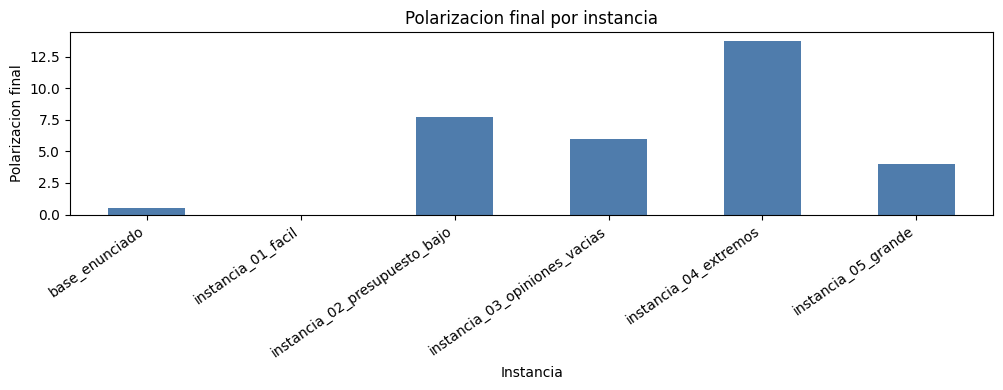

In [68]:
ax = df.plot(
    kind='bar', x='instancia', y='polarizacion', legend=False,
    figsize=(10, 4), color='#4f7cac', title='Polarizacion final por instancia'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Polarizacion final')
plt.xticks(rotation=35, ha='right')
guardar('01_polarizacion_instancias_propias.png')


**Conclusion:** la polarizacion minima es `0.00` en `instancia_01_facil`, mientras que la maxima es `13.75` en `instancia_04_extremos`. La diferencia se explica por la distribucion inicial: la instancia facil permite concentrar la poblacion, pero la instancia de extremos parte con opiniones muy separadas. Esta comparacion muestra que la calidad final no depende solo del presupuesto, sino tambien de la forma inicial de la poblacion.


## Figura 2. Presupuesto y movimientos utilizados

**Proposito:** comparar conjuntamente el porcentaje de presupuesto usado y el porcentaje de movimientos usados.

**Por que es adecuada:** una grafica de barras agrupadas permite ver si domina la restriccion de costo, la de movimientos o ambas. Esto evita analizar presupuesto y movimientos en secciones separadas.


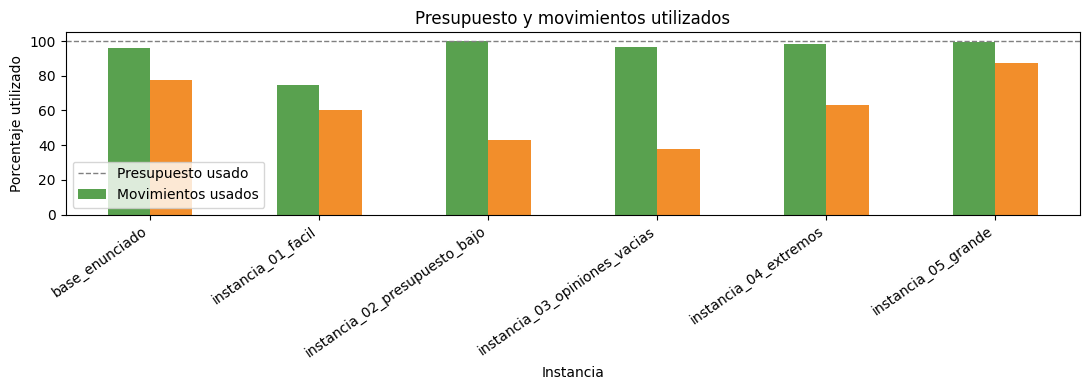

In [69]:
recursos = df[['instancia', 'porcentaje_presupuesto', 'porcentaje_movimientos']].copy()
ax = recursos.plot(
    kind='bar', x='instancia', y=['porcentaje_presupuesto', 'porcentaje_movimientos'],
    figsize=(11, 4), color=['#59a14f', '#f28e2b'],
    title='Presupuesto y movimientos utilizados'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Porcentaje utilizado')
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.legend(['Presupuesto usado', 'Movimientos usados'])
plt.xticks(rotation=35, ha='right')
guardar('02_recursos_presupuesto_movimientos.png')


**Conclusion:** cinco de las seis instancias usan mas del 95 % del presupuesto. En `instancia_02_presupuesto_bajo` se usa el 100 % del presupuesto, pero solo el 42.86 % de los movimientos; por eso, alli domina la restriccion de costo. En `instancia_05_grande` se usa el 99.29 % del presupuesto y el 87.50 % de movimientos, lo que indica que ambas restricciones quedan ajustadas.


## Tabla 2. Personas movidas por instancia

La cantidad de personas movidas se deja como tabla complementaria, porque no se conserva como grafica principal.


In [70]:
df[['instancia', 'personas_movidas', 'polarizacion', 'movimientos_realizados']]


,instancia,personas_movidas,polarizacion,movimientos_realizados
0,base_enunciado,8,0.50,2->1: 4; 4->1: 2; 4->2: 2
1,instancia_01_facil,9,0.00,1->2: 7; 3->2: 2
2,instancia_02_presupuesto_bajo,4,7.75,5->2: 1; 5->4: 3
3,instancia_03_opiniones_vacias,3,6.00,5->3: 3
4,instancia_04_extremos,19,13.75,1->2: 13; 5->4: 6
5,instancia_05_grande,18,4.00,1->2: 6; 2->4: 3; 5->4: 9


**Lectura:** `instancia_04_extremos` mueve 19 personas y queda con polarizacion `13.75`; la instancia base mueve 8 personas y queda con polarizacion `0.50`. Esto muestra que mover mas personas no garantiza menor polarizacion: importa la distancia ideologica y la posicion final respecto a la mediana.


## Tabla 3. Bateria del profesor

Esta tabla compara el resultado del modelo contra el valor esperado entregado por el profesor.


In [71]:
cols_bateria = [
    'instancia', 'n', 'm', 'estado_solver', 'polarizacion',
    'valor_esperado', 'diferencia_abs', 'comparacion_esperada',
    'tiempo_segundos', 'observaciones'
]
bateria[cols_bateria]


,instancia,n,m,estado_solver,polarizacion,valor_esperado,diferencia_abs,comparacion_esperada,tiempo_segundos,observaciones
0,MinPol1,5,5,optimo,0.090,0.090,0.000,coincide,0.1280,NaN
1,MinPol2,5,5,optimo,0.000,0.000,0.000,coincide,0.0924,NaN
2,MinPol3,5,10,optimo,0.000,0.000,0.000,coincide,0.1356,NaN
3,MinPol4,10,5,optimo,0.000,0.000,0.000,coincide,0.1056,NaN
4,MinPol5,10,5,optimo,0.482,0.482,0.000,coincide,0.1241,NaN
5,MinPol6,20,5,optimo,0.003,0.003,0.000,coincide,0.1077,NaN
6,MinPol7,35,5,optimo,3.085,3.085,0.000,coincide,0.1658,NaN
7,MinPol8,35,5,optimo,4.323,4.323,0.000,coincide,0.0995,NaN
8,MinPol9,50,5,optimo,5.373,5.373,0.000,coincide,0.0987,NaN
9,MinPol10,50,5,optimo,9.687,9.686,0.001,coincide,0.0898,NaN


## Figura 3. Estado de las instancias de la bateria

**Proposito:** resumir cuantas instancias fueron resueltas hasta optimalidad y cuantas presentaron problemas.

**Por que es adecuada:** el estado del solver es una variable categorica, por lo que una grafica de barras por estado resume bien el resultado general de la bateria.


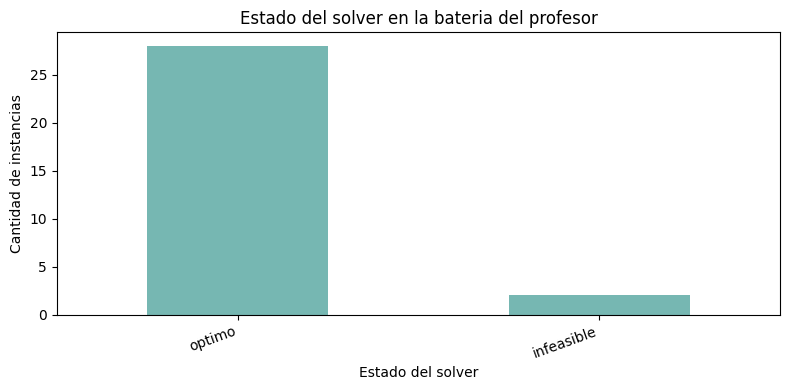

In [72]:
estado_counts = bateria['estado_solver'].value_counts()
ax = estado_counts.plot(
    kind='bar', figsize=(8, 4), color='#76b7b2',
    title='Estado del solver en la bateria del profesor'
)
ax.set_xlabel('Estado del solver')
ax.set_ylabel('Cantidad de instancias')
plt.xticks(rotation=20, ha='right')
guardar('03_estado_solver_bateria.png')


**Conclusion:** 28 instancias de la bateria llegan a estado optimo y 2 aparecen como infactibles. Las infactibles son `MinPol28` y `MinPol29`, cuyos datos declaran `n = 100` pero tienen una distribucion inicial que suma `125`. Por eso se interpretan como entradas inconsistentes, no como fallos del modelo.


## Figura 4. Valor obtenido frente a valor esperado

**Proposito:** validar que la polarizacion calculada por el modelo coincide con la solucion esperada del profesor.

**Por que es adecuada:** al graficar ambas series sobre las mismas instancias, la coincidencia visual entre curvas facilita detectar desviaciones.


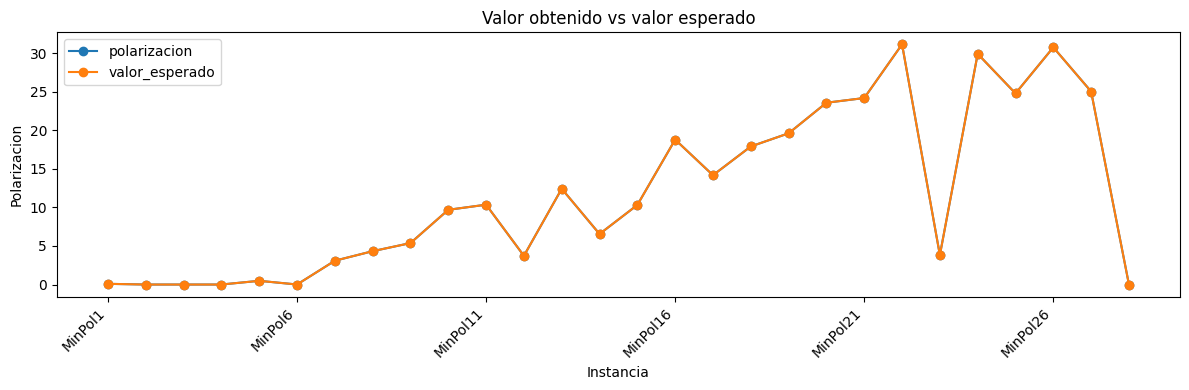

In [73]:
comparables = bateria[bateria['comparacion_esperada'].isin(['coincide', 'diferente'])].copy()
ax = comparables.plot(
    x='instancia', y=['polarizacion', 'valor_esperado'],
    figsize=(12, 4), marker='o', title='Valor obtenido vs valor esperado'
)
ax.set_xlabel('Instancia')
ax.set_ylabel('Polarizacion')
plt.xticks(rotation=45, ha='right')
guardar('04_valor_obtenido_vs_esperado.png')


**Conclusion:** las 28 instancias comparables coinciden con el valor esperado usando tolerancia de `0.01`. Las pequenas diferencias, como `0.001`, corresponden a redondeo decimal. Por eso la grafica de diferencia absoluta no se conserva como figura principal y se resume en tabla.


## Tabla 4. Resumen de diferencias contra el esperado


In [74]:
resumen_diferencias = pd.DataFrame({
    'criterio': ['Instancias comparables', 'Coincidencias dentro de tolerancia 0.01', 'Diferencia maxima observada'],
    'valor': [
        len(comparables),
        (comparables['comparacion_esperada'] == 'coincide').sum(),
        comparables['diferencia_abs'].max()
    ]
})
resumen_diferencias


,criterio,valor
0,Instancias comparables,28.000
1,Coincidencias dentro de tolerancia 0.01,28.000
2,Diferencia maxima observada,0.001


## Figura 5. Tamano de la instancia frente al tiempo

**Proposito:** analizar si el tiempo de ejecucion aumenta con el tamano estructural del problema.

**Por que es adecuada:** la variable principal `x[i,j]` considera pares de opiniones, por eso `m^2` aproxima mejor el crecimiento del modelo que usar solo `m`.


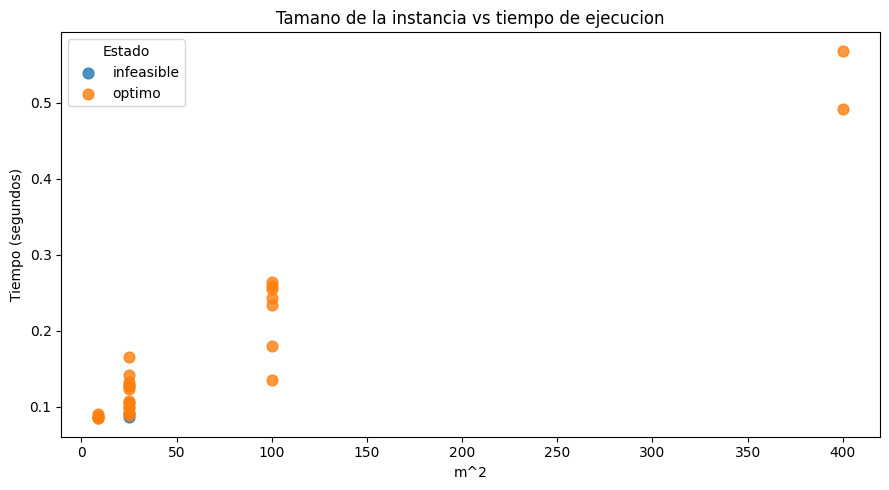

In [75]:
bateria_tam = bateria.copy()
bateria_tam['m2'] = bateria_tam['m'] ** 2

fig, ax = plt.subplots(figsize=(9, 5))
for estado, data in bateria_tam.groupby('estado_solver'):
    ax.scatter(data['m2'], data['tiempo_segundos'], label=estado, s=60, alpha=0.8)
ax.set_title('Tamano de la instancia vs tiempo de ejecucion')
ax.set_xlabel('m^2')
ax.set_ylabel('Tiempo (segundos)')
ax.legend(title='Estado')
guardar('05_tamano_vs_tiempo_bateria.png')


**Conclusion:** el tiempo no crece de forma perfectamente lineal con `m^2`. Algunas instancias grandes se resuelven rapido, mientras que otras pueden requerir mas busqueda. Esto indica que el rendimiento depende del tamano, pero tambien de la distribucion inicial, costos, presupuesto y limite de movimientos.


## Conclusiones generales

- El modelo resolvio como optimas la instancia base y las cinco instancias propias.
- En la bateria del profesor, 28 instancias consistentes coincidieron con el valor esperado.
- `MinPol28` y `MinPol29` son infactibles por inconsistencia entre `n` y la suma de la distribucion inicial.
- En cinco de las seis instancias propias se uso mas del 95 % del presupuesto, lo que muestra que el costo total fue una restriccion dominante.
- La cantidad de personas movidas debe interpretarse junto con polarizacion, costo y movimientos: no basta con mover mas personas para obtener una mejor solucion.
